In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
lab2text = pd.read_csv("../processed/labels.csv")
lab2text = {_id: lab for _id, lab in zip(lab2text['id'], lab2text['label'])}

In [3]:
df = pd.read_parquet("../processed/test.parquet")
df.head()

,features,label
0,"[0.37898833, 0.12232772, 0.0, 0.1403418, 0.408...",0
1,"[0.30911183, 0.07769062, 0.0, 0.19287993, 0.48...",0
2,"[0.31679192, 0.08381651, 0.0, 0.19153045, 0.47...",0
3,"[0.35052165, 0.10881082, 0.0, 0.16769895, 0.43...",0
4,"[0.27369457, 0.051589057, 0.0, 0.20084615, 0.4...",0


In [4]:
test_set = df.loc[:5]
#test_set['features'].loc[0]

In [5]:
HAND_CONNECTIONS = [
    (0, 1), (1, 2), (2, 3), (3, 4),      # Thumb
    (0, 5), (5, 6), (6, 7), (7, 8),      # Index finger
    (0, 9), (9, 10), (10, 11), (11, 12), # Middle finger
    (0, 13), (13, 14), (14, 15), (15, 16), # Ring finger
    (0, 17), (17, 18), (18, 19), (19, 20)  # Pinky
]

def draw_landmarks_from_features(features, title="Original"):
    """
    Draw right & left hand skeleton from the 84-dim feature vector.
    """
    # Extract coordinates
    rx = features[0:21]
    ry = features[21:42]
    lx = features[42:63]
    ly = features[63:84]

    plt.figure(figsize=(5, 5))
    ax = plt.gca()

    plt.plot([0, 1], [0, 1], alpha=0)

    # Draw Right Hand
    if not np.allclose(rx, 0):
        for a, b in HAND_CONNECTIONS:
            plt.plot([rx[a], rx[b]], [ry[a], ry[b]], linewidth=2)
        plt.scatter(rx, ry, s=15)

    # Draw Left Hand
    if not np.allclose(lx, 0):
        for a, b in HAND_CONNECTIONS:
            plt.plot([lx[a], lx[b]], [ly[a], ly[b]], linewidth=2)
        plt.scatter(lx, ly, s=15)

    # Flip y-axis (Mediapipe uses top-left origin)
    plt.gca().invert_yaxis()
    plt.xlim(0, 1)
    plt.ylim(1, 0)
    plt.title(title + " Hand Landmarks")
    plt.axis("equal")
    plt.savefig(f"{title}_landmarks.png")
    plt.show()


In [6]:
features = test_set['features'].loc[0]
label = test_set['label'].loc[0]
features.shape, lab2text[label]

((84,), '1')

In [7]:
def horizontal_flip(gesture: np.ndarray) -> np.ndarray:
    """Horizontally flip gesture and swap hand positions.

    After flipping, what was right hand becomes left hand and vice versa.

    Args:
        gesture (np.ndarray): Array of features

    Returns:
        np.ndarray: Horizontally flipped features with hands swapped
    """
    flipped_gesture = np.zeros_like(gesture)
    
    # Copy and flip right hand to left hand position
    if not np.allclose(gesture[0:21], 0):  # If right hand exists
        # Flip x-coordinates and place in left hand section
        flipped_gesture[42:63] = 1 - gesture[0:21]    # x-coords
        flipped_gesture[63:84] = gesture[21:42]       # y-coords (unchanged)
    
    # Copy and flip left hand to right hand position
    if not np.allclose(gesture[42:63], 0):  # If left hand exists
        # Flip x-coordinates and place in right hand section
        flipped_gesture[0:21] = 1 - gesture[42:63]    # x-coords
        flipped_gesture[21:42] = gesture[63:84]       # y-coords (unchanged)
    
    return flipped_gesture

def add_noise(
        gesture:np.ndarray, 
        mean: float,
        std: float
    ) -> np.ndarray:
    """Adds Gaussian noise to gesture landmarks

    Args:
        gesture (np.ndarray): Array of features
        mean (float): Mean
        std (float): Std

    Returns:
        np.ndarray: Features with noise applied
    """
    new_gesture = np.copy(gesture)
    noise = np.random.normal(mean, std, 84)
    for i in range(len(gesture)):
        # Checking if hand exists
        if new_gesture[i] != 0:
            new_gesture[i] += noise[i]
    return new_gesture

def random_translate(
        gesture: np.ndarray
    ) -> np.ndarray:
    """Randomly moves gesture landmarks

    Args:
        gesture (np.ndarray): Array of features

    Returns:
        np.ndarray: Features with some translation
    """
    new_gesture = np.copy(gesture)
    x_translate = np.random.rand()
    y_translate = np.random.rand()
    
    # Checking each hand
    if not np.allclose(gesture[:21], 0):
        new_gesture[:21] += x_translate
        new_gesture[21:42] += y_translate
    if not np.allclose(gesture[42:63], 0):
        new_gesture[42:63] += x_translate
        new_gesture[63:84] += y_translate
    
    return new_gesture

def random_scale(
        gesture: np.ndarray
    ) -> np.ndarray:
    """Randomly scales gesture landmarks

    Args:
        gesture (np.ndarray): Array of features

    Returns:
        np.ndarray: Features with some scale
    """
    scale_factor = np.random.rand()
    scaled_gesture = gesture * scale_factor
    
    return scaled_gesture

def random_rotate(
        gesture: np.ndarray
    ) -> np.ndarray:
    """Randomly rotaset gesture. Maximum 15 degree

    Args:
        gesture (np.ndarray): Array of features

    Returns:
        np.ndarray: Features with some rotation
    """
    # Some vars
    angle_rad = np.deg2rad(np.random.uniform(-15, 15))
    cos_angle = np.cos(angle_rad)
    sin_angle = np.sin(angle_rad)

    rotation_matrix = np.array([[cos_angle, -sin_angle],
                                 [sin_angle, cos_angle]])

    new_gesture = np.copy(gesture)

    # Rotating gesture
    for hand_start in [0, 42]:
        if not np.allclose(gesture[hand_start:hand_start + 21], 0):
            for i in range(21):
                point = np.array([gesture[hand_start + i], gesture[hand_start + 21 + i]])
                rotated_point = rotation_matrix @ point
                new_gesture[hand_start + i] = rotated_point[0]
                new_gesture[hand_start + 21 + i] = rotated_point[1]

    return new_gesture

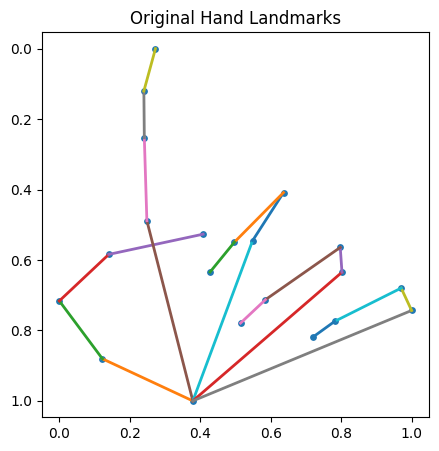

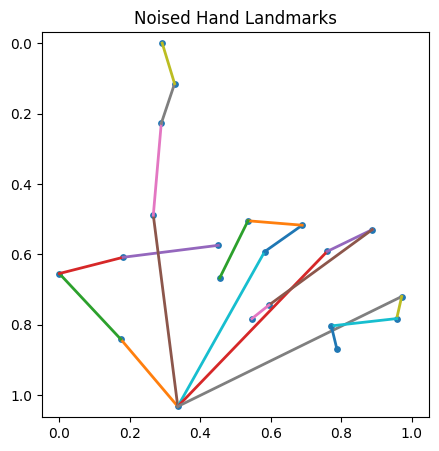

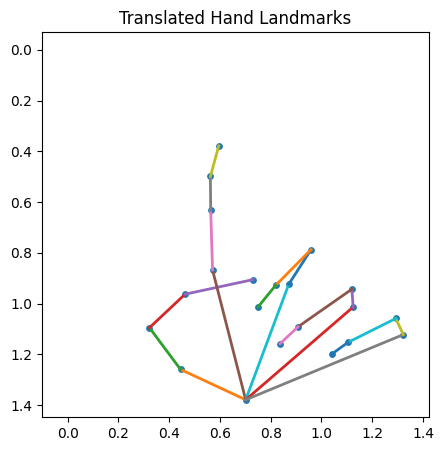

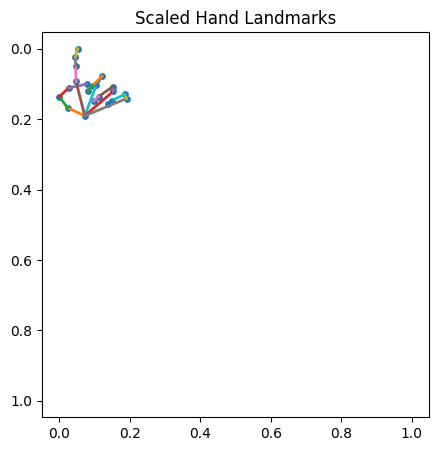

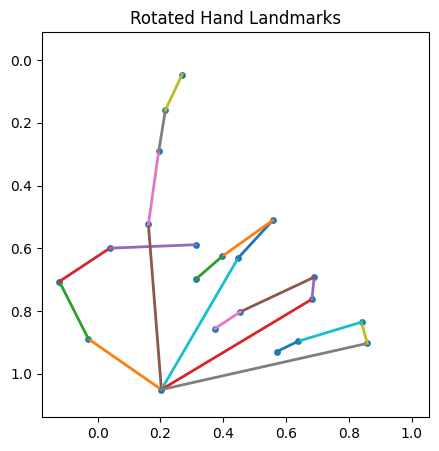

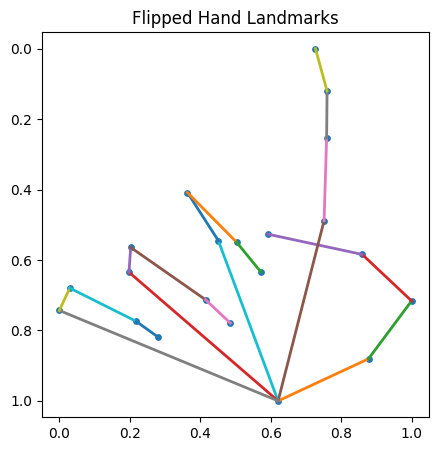

In [9]:
noised = add_noise(features, mean=0.01, std=0.04)
translated = random_translate(features)
scaled = random_scale(features)
rotated = random_rotate(features)
flipped = horizontal_flip(features)

draw_landmarks_from_features(features)
draw_landmarks_from_features(noised, "Noised")
draw_landmarks_from_features(translated, "Translated")
draw_landmarks_from_features(scaled, "Scaled")
draw_landmarks_from_features(rotated, "Rotated")
draw_landmarks_from_features(flipped, "Flipped")